# **Exploratory Data Analysis & Feature Space Representation**

Mục tiêu cốt lõi của là khai phá các đặc trưng phân phối dữ liệu từ tập bình luận đã qua tiền xử lý, đồng thời tiến hành các kiểm định giả thuyết thống kê để khám phá hành vi ngôn ngữ của người dùng. Trọng tâm của phân tích là sự so sánh đối chiếu có hệ thống giữa hai phương pháp biểu diễn không gian đặc trưng: Mô hình phân phối thưa  và Mô hình nhúng ngữ nghĩa dày đặc. Thông qua việc đánh giá định lượng khả năng phân tách tuyến tính của cả hai không gian này, chúng ta sẽ thiết lập nền tảng lý thuyết vững chắc để ra quyết định kiến trúc mô hình học máy trong các giai đoạn tiếp theo.

---

## **0. Environment Setup & Data Loading**


### **0.1. Import Libraries**

Tiến hành thiết lập môi trường bằng cách nhập các thư viện phân tích dữ liệu, kiểm định thống kê và trực quan hóa chuyên dụng. Bộ dữ liệu `processed_labeled_reviews.csv` chứa các bình luận thương mại điện tử đã được chuẩn hóa, tokenize và gán nhãn sẽ được nạp vào bộ nhớ để bắt đầu quá trình phân tích.

In [5]:
# 1. Data manipulation and statistical testing
import pandas as pd
import numpy as np
import scipy.stats as stats
from collections import Counter

# 2. Visualization
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from wordcloud import WordCloud

# 3. Natural language processing and feature extraction
from sklearn.feature_extraction.text import TfidfVectorizer

# 4. Machine learning: clustering, dimensionality reduction, and baseline models
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import LabelEncoder

# 5. Sentence embeddings
from sentence_transformers import SentenceTransformer

# Global display settings for pandas and matplotlib
pd.set_option("display.max_colwidth", 80)
pd.set_option("display.float_format", "{:.4f}".format)
plt.style.use("seaborn-v0_8-whitegrid")
sns.set_palette("husl")
SEED = 42

c:\Users\ADMIN\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### **0.2. Load Dataset**

Đọc tập dữ liệu đã qua tiền xử lý (`processed_labeled_reviews.csv`) vào bộ nhớ. Kiểm tra nhanh số lượng mẫu, số lượng đặc trưng và kiểu dữ liệu của từng trường để đảm bảo dữ liệu đã sẵn sàng cho quá trình phân tích.

In [6]:
# Path to the preprocessed and labeled dataset
DATA_PATH = "../data/processed/processed_labeled_reviews.csv"
df = pd.read_csv(DATA_PATH)

# Verify dataset dimensions and overall structure
print(f"Dataset shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
print()
df.info()

Dataset shape: 4,651 rows x 6 columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4651 entries, 0 to 4650
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   text             4651 non-null   object
 1   cleaned_text     4651 non-null   object
 2   rating           4651 non-null   int64 
 3   sentiment_label  4651 non-null   object
 4   tokens_word      4651 non-null   object
 5   tokens_subword   4651 non-null   object
dtypes: int64(1), object(5)
memory usage: 218.1+ KB


In [7]:
# Preview the data to confirm successful loading
display(df.head())

,text,cleaned_text,rating,sentiment_label,tokens_word,tokens_subword
0,Đọc quá trời hay luôn á 5⭐️ Kh có ảnh nên lấy đại,đọc quá trời hay luôn á 5 tuyệt_vời không có ảnh nên lấy đại,5,tích cực,đọc quá trời hay luôn á 5 tuyệt_vời không có ảnh nên lấy đại,đọc quá trời hay luôn á 5 tuyệt_vời không có ảnh nên lấy đại
1,"Hay nha, sẽ ủng hộ dài dài, đóng gói oki","hay nha , sẽ ủng_hộ dài_dài , đóng_gói oki",5,tích cực,"hay nha , sẽ ủng_hộ dài_dài , đóng_gói oki","hay nha , sẽ ủng_hộ dài_dài , đóng_gói o@@ ki"
2,"Nội dung gần gũi, sách đẹp, giao hàng nhanh, đóng gói cẩn thận.","nội_dung gần_gũi , sách_đẹp , giao hàng nhanh , đóng_gói cẩn_thận .",5,tích cực,"nội_dung gần_gũi , sách_đẹp , giao hàng nhanh , đóng_gói cẩn_thận .","nội_dung gần_gũi , sách_@@ đẹp , giao hàng nhanh , đóng_gói cẩn_thận ."
3,"Date xa , tui rất thích .Cả 3 loại dòng LipIce Sheer Color tui xài hết rồi ,...","hạn sử_dụng xa , tui rất thích . cả 3 loại dòng lipice sheer color tui dùng ...",5,tích cực,"hạn sử_dụng xa , tui rất thích . cả 3 loại dòng lipice sheer color tui dùng ...","hạn sử_dụng xa , tui rất thích . cả 3 loại dòng lip@@ ice she@@ er color tui..."
4,"Điện thoại đag bị hư k up ảnh sản phẩm đc 🤭 nhưng Tiki gửi hàng date xa , ba...",điện_thoại đag bị hư không up_ảnh sản_phẩm được nhưng tiki gửi hàng hạn sử_d...,5,tích cực,điện_thoại đag bị hư không up_ảnh sản_phẩm được nhưng tiki gửi hàng hạn sử_d...,điện_thoại đa@@ g bị hư không u@@ p_@@ ảnh sản_phẩm được nhưng ti@@ ki gửi h...


---
## **1. Class Imbalance Analysis**

Phân tích phân phối nhãn là bước tiên quyết trong mọi pipeline học máy. Đối với văn bản đánh giá thương mại điện tử, dữ liệu thực tế hiếm khi đạt trạng thái cân bằng tự nhiên; người dùng thường có xu hướng để lại đánh giá tích cực (5 sao) nhiều hơn hẳn so với đánh giá tiêu cực hoặc trung lập. Sự mất cân bằng dữ liệu ở mức độ nghiêm trọng sẽ tạo ra độ lệch lớn cho mô hình, khiến mô hình ưu tiên dự đoán lớp đa số và bỏ qua các đặc trưng vi mô của lớp thiểu số.

Trong phần này, chúng ta sẽ:
1. Trực quan hóa phân phối nhãn cảm xúc (`sentiment_label`) và phân phối số sao (`rating`).
2. Tính toán tỷ lệ phần trăm chính xác của từng lớp để định lượng mức độ mất cân bằng.
3. Đề xuất chiến lược giảm thiểu phù hợp cho giai đoạn huấn luyện.

### **1.1. Sentiment Label Distribution**

Thống kê số lượng và trực quan hóa tỷ lệ phần trăm của từng nhãn cảm xúc (Tích cực, Tiêu cực, Trung lập).

In [10]:
# Count samples per sentiment label
sentiment_counts = df["sentiment_label"].value_counts()
sentiment_pct    = df["sentiment_label"].value_counts(normalize=True).mul(100).round(2)

# Summarize into a table for easy inspection
sentiment_summary = pd.DataFrame({
    "Count":      sentiment_counts,
    "Percentage": sentiment_pct.astype(str) + " %"
})
sentiment_summary.index.name = "Sentiment Label"
print("Sentiment Label Distribution:")
display(sentiment_summary)

Sentiment Label Distribution:


,Count,Percentage
Sentiment Label,,
tích cực,4371,93.98 %
tiêu cực,230,4.95 %
trung lập,50,1.08 %


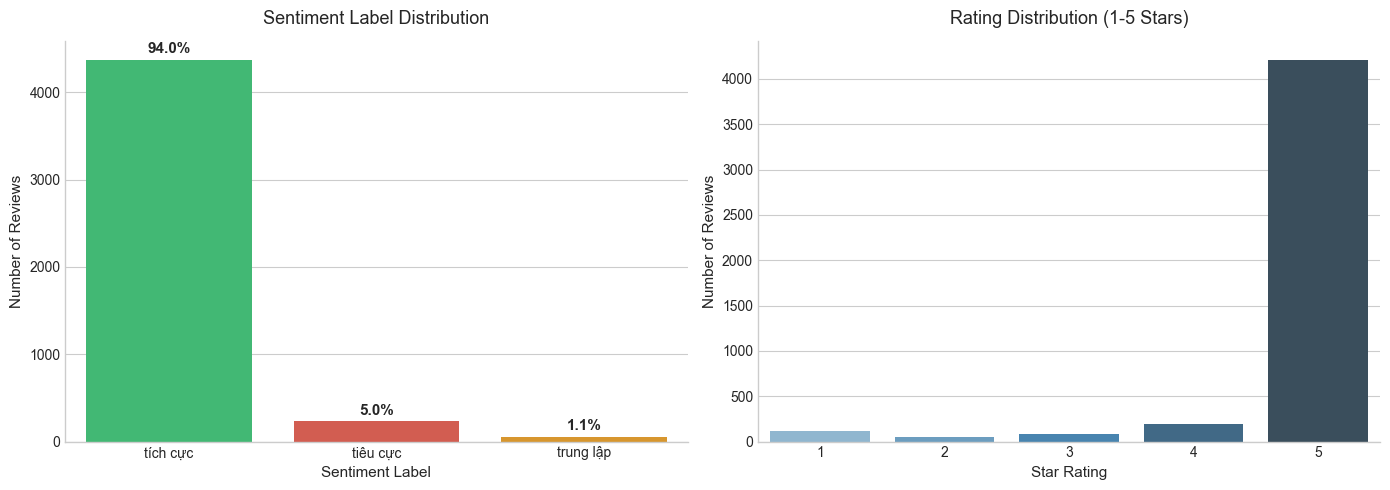

In [11]:
# Visualize sentiment label distribution as bar charts
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left plot: sentiment label distribution
palette_sentiment = {"tich cuc": "#2ECC71", "trung lap": "#F39C12", "tieu cuc": "#E74C3C"}
palette_sentiment = {"tích cực": "#2ECC71", "trung lập": "#F39C12", "tiêu cực": "#E74C3C"}
bar_ax = sns.barplot(
    x=sentiment_counts.index,
    y=sentiment_counts.values,
    hue=sentiment_counts.index,
    palette=palette_sentiment,
    ax=axes[0],
    legend=False,
)
# Annotate percentage labels above each bar
for patch, (label, pct) in zip(bar_ax.patches, sentiment_pct.items()):
    bar_ax.text(
        patch.get_x() + patch.get_width() / 2,
        patch.get_height() + sentiment_counts.max() * 0.01,
        f"{pct:.1f}%",
        ha="center", va="bottom", fontsize=11, fontweight="bold",
    )
axes[0].set_title("Sentiment Label Distribution", fontsize=13, pad=12)
axes[0].set_xlabel("Sentiment Label", fontsize=11)
axes[0].set_ylabel("Number of Reviews", fontsize=11)
sns.despine(ax=axes[0], top=True, right=True)

# Right plot: star rating distribution (1-5 stars)
rating_counts = df["rating"].value_counts().sort_index()
sns.barplot(
    x=rating_counts.index,
    y=rating_counts.values,
    hue=rating_counts.index.astype(str),
    palette="Blues_d",
    ax=axes[1],
    legend=False,
)
axes[1].set_title("Rating Distribution (1-5 Stars)", fontsize=13, pad=12)
axes[1].set_xlabel("Star Rating", fontsize=11)
axes[1].set_ylabel("Number of Reviews", fontsize=11)
sns.despine(ax=axes[1], top=True, right=True)

plt.tight_layout()
plt.show()

**Nhận xét từ biểu đồ phân phối:**

- **Mất cân bằng dữ liệu nghiêm trọng:** Biểu đồ "Sentiment Label Distribution" cho thấy nhãn tích cực chiếm tỷ trọng áp đảo lên tới 94.0%, trong khi nhãn tiêu cực chỉ chiếm 5.0% và trung lập là 1.1%. 
- **Tương quan với số sao:** Sự phân bố của nhãn cảm xúc hoàn toàn đồng nhất với phân bố số sao. Lượng đánh giá 5 sao chiếm gần như toàn bộ tập dữ liệu, phản ánh hành vi thực tế của người dùng thường có xu hướng để lại đánh giá tích cực khi mua hàng trực tuyến.
- **Hệ quả cho mô hình học máy:** Sự mất cân bằng này sẽ khiến mô hình dễ bị lệch, có xu hướng dự đoán toàn bộ các mẫu là tích cực để đạt độ chính xác cao nhưng lại bỏ sót hoàn toàn các bình luận tiêu cực và trung lập - vốn là những nhãn quan trọng nhất cần nhận diện.


### **1.2. Imbalance Ratio & Mitigation Strategy**


**Chiến lược giảm thiểu:**

| Phương pháp | Cơ chế | Phù hợp khi |
|---|---|---|
| **Class Weights** | Tăng penalize (phạt) lỗi trên lớp thiểu số trong hàm mất mát | Mất cân bằng nhẹ–vừa |
| **SMOTE / Oversampling** | Tổng hợp mẫu nhân tạo cho lớp thiểu số trong không gian đặc trưng | Mất cân bằng vừa–nặng |
| **Undersampling đa số** | Giảm ngẫu nhiên lượng mẫu của lớp đa số | Tập dữ liệu rất lớn |
| **Thay đổi độ đo đánh giá** | Đánh giá mô hình bằng **F1-Macro, Precision, Recall** thay vì **Accuracy** để đo lường công bằng hiệu suất trên nhóm thiểu số | Mọi trường hợp có dữ liệu mất cân bằng |


> Trong pipeline này, **Class Weights** (`class_weight='balanced'`) sẽ được ưu tiên sử dụng cho các mô hình scikit-learn do tính đơn giản và hiệu quả đã được kiểm chứng. 

---
## **2. Text Length Exploration & Statistical Hypothesis Testing**

**Giả thuyết thống kê:** *"Các bình luận tiêu cực thường có độ dài văn bản lớn hơn các bình luận tích cực, do những khách hàng không hài lòng có xu hướng miêu tả chi tiết lỗi sản phẩm và trải nghiệm tồi tệ của họ."*

Vì phân phối độ dài văn bản tự nhiên tuân theo phân phối lệch (như Log-Normal hoặc Poisson) và hiếm khi đạt phân phối chuẩn, việc sử dụng kiểm định tham số t-test có thể dẫn đến sai lầm loại I. Do đó, chúng ta sẽ áp dụng kiểm định phi tham số Mann-Whitney U Test để đánh giá sự khác biệt có ý nghĩa thống kê về trung vị độ dài giữa hai quần thể bình luận Tích cực vs. Tiêu cực.



### **2.1. Feature Engineering — Text Length Metrics**

Tạo thêm các đặc trưng thống kê về độ dài văn bản bao gồm số lượng từ (`word_count`) và số lượng ký tự (`char_count`) cho mỗi bình luận. Sau đó, tính toán các đại lượng thống kê mô tả và vẽ biểu đồ KDE, Boxplot để so sánh trực quan sự khác biệt về độ dài giữa các nhóm cảm xúc.

In [12]:
# Compute basic text length metrics
df["word_count"] = df["cleaned_text"].astype(str).apply(lambda x: len(x.split()))
df["char_count"] = df["cleaned_text"].astype(str).apply(len)

# Aggregate length statistics by sentiment label
length_stats = (
    df.groupby("sentiment_label")[["word_count", "char_count"]]
    .agg(["mean", "median", "std"])
    .round(2)
)
length_stats.columns = ["Word Mean", "Word Median", "Word Std",
                         "Char Mean", "Char Median", "Char Std"]
length_stats.index.name = "Sentiment Label"

print("Text Length Statistics by Sentiment Class:")
display(length_stats)

Text Length Statistics by Sentiment Class:


,Word Mean,Word Median,Word Std,Char Mean,Char Median,Char Std
Sentiment Label,,,,,,
tiêu cực,22.7900,15.0000,23.7500,107.6400,68.5000,115.3400
trung lập,16.4600,11.0000,14.4900,78.3000,54.5000,72.2400
tích cực,18.1400,16.0000,15.2200,91.7200,79.0000,79.0800


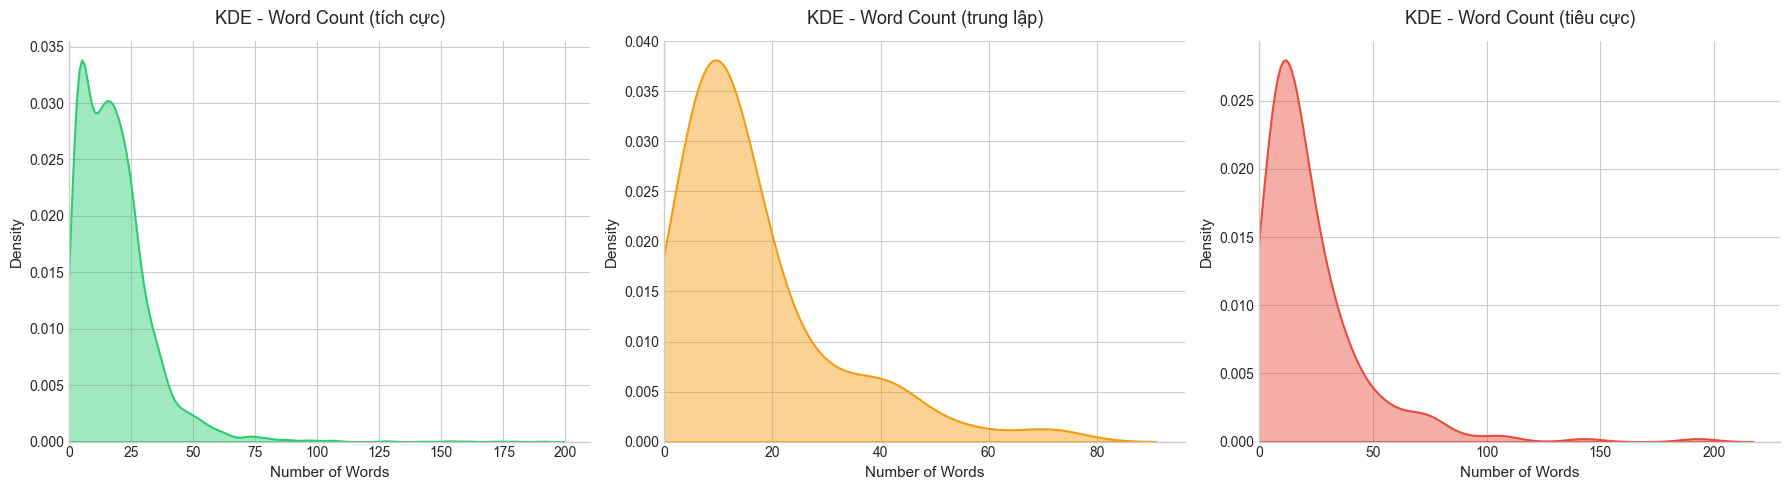

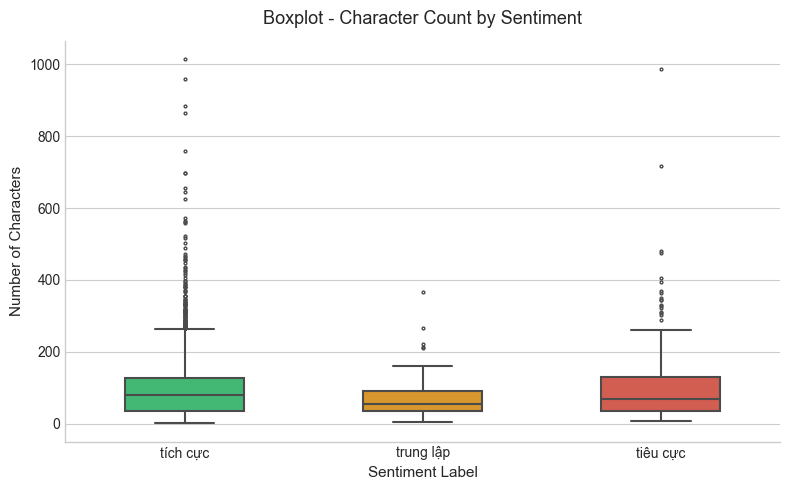

In [28]:
# Visualize text length distributions by sentiment label

palette_map = {"tích cực": "#2ECC71", "trung lập": "#F39C12", "tiêu cực": "#E74C3C"}
labels = ["tích cực", "trung lập", "tiêu cực"]

# 1. Plot 3 KDE distributions in a single figure (1 row, 3 columns)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, label in enumerate(labels):
    color = palette_map[label]
    subset = df[df["sentiment_label"] == label]["word_count"].dropna()
    
    if len(subset) > 0:
        sns.kdeplot(subset, fill=True, color=color, alpha=0.45,
                    linewidth=1.5, ax=axes[i])
        
    axes[i].set_title(f"KDE - Word Count ({label})", fontsize=13, pad=12)
    axes[i].set_xlabel("Number of Words", fontsize=11)
    axes[i].set_ylabel("Density", fontsize=11)
    axes[i].set_xlim(left=0)
    sns.despine(ax=axes[i], top=True, right=True)

plt.tight_layout()
plt.show() # Display the first figure (3 KDE plots)


# 2. Plot the Boxplot in a separate figure
plt.figure(figsize=(8, 5))
sns.boxplot(
    data=df,
    x="sentiment_label",
    y="char_count",
    hue="sentiment_label",
    palette=palette_map,
    order=["tích cực", "trung lập", "tiêu cực"],
    width=0.5, linewidth=1.5, fliersize=2,
    legend=False,
)
plt.title("Boxplot - Character Count by Sentiment", fontsize=13, pad=12)
plt.xlabel("Sentiment Label", fontsize=11)
plt.ylabel("Number of Characters", fontsize=11)
sns.despine(top=True, right=True)
plt.tight_layout()
plt.show() # Display the second figure (Boxplot)

**Nhận xét:**

1. **Bình luận tiêu cực dài hơn:** Độ dài trung bình của nhóm tiêu cực cao nhất (~22.8 từ) so với tích cực (~18.1 từ) và trung lập (~16.5 từ), do khách hàng thường miêu tả lỗi chi tiết khi không hài lòng.
2. **Khác biệt rõ rệt ở phần đuôi:** Mặc dù đỉnh phân phối của cả 3 nhóm đều nằm dưới 20 từ, nhóm tiêu cực có đuôi kéo rất dài tới 150-200 từ. Ngược lại, nhóm tích cực và trung lập gần như chạm mức 0 ngay từ mốc 75 từ.
3. **Giá trị bổ sung cho mô hình:** Sự khác biệt rõ rệt này chứng tỏ `word_count` và `char_count` là những đặc trưng hữu ích. Có thể nối chúng với TF-IDF hoặc Word Embeddings để cải thiện độ chính xác của mô hình ở bước sau.
4. **Nhóm trung lập ngắn gọn và ít biến động nhất:** Cả thống kê và biểu đồ Boxplot đều cho thấy nhóm trung lập có dải phân tán hẹp nhất và rất ít điểm ngoại lai. Người dùng ở nhóm này có xu hướng chỉ để lại vài từ cụt lủn, chung chung (ví dụ: "bình thường", "tạm ổn") mà không có nhu cầu giải thích thêm.

### **2.2. Mann-Whitney U Test**

Thực hiện kiểm định thống kê phi tham số để chứng minh một cách khoa học và chặt chẽ rằng: *"Khách hàng thực sự viết bình luận tiêu cực dài hơn bình luận tích cực"*, thay vì chỉ ước lượng bằng mắt qua biểu đồ. Chúng ta buộc phải dùng kiểm định phi tham số này vì phân phối số lượng từ vựng bị lệch và không tuân theo phân phối chuẩn.


In [18]:
# Extract word counts by sentiment group for hypothesis testing
pos_lengths = df[df["sentiment_label"] == "tích cực"]["word_count"].dropna()
neg_lengths = df[df["sentiment_label"] == "tiêu cực"]["word_count"].dropna()

# Mann-Whitney U Test (alternative='greater': negative > positive)
# H0: the length distribution of negative reviews <= positive reviews
# H1: the length distribution of negative reviews > positive reviews  (one-tailed)
u_stat, p_value = stats.mannwhitneyu(neg_lengths, pos_lengths, alternative="greater")

# Compute effect size r = Z / sqrt(N) to evaluate practical significance
n1, n2 = len(neg_lengths), len(pos_lengths)
z_approx = (u_stat - n1 * n2 / 2) / np.sqrt(n1 * n2 * (n1 + n2 + 1) / 12)
effect_r = abs(z_approx) / np.sqrt(n1 + n2)

# Summarize test results into a display table
test_result = pd.DataFrame({
    "Metric": [
        "Mann-Whitney U Statistic",
        "P-value (one-tailed)",
        "Effect Size r",
        "Median Word Count (Negative)",
        "Median Word Count (Positive)",
        "Statistical Decision (alpha=0.05)",
    ],
    "Value": [
        f"{u_stat:,.0f}",
        f"{p_value:.6f}",
        f"{effect_r:.4f}",
        f"{neg_lengths.median():.1f}",
        f"{pos_lengths.median():.1f}",
        "Reject H0" if p_value < 0.05 else "Fail to Reject H0",
    ]
})
test_result = test_result.reset_index()
print("Mann-Whitney U Test Results:")
display(test_result)

Mann-Whitney U Test Results:


,index,Metric,Value
0,0,Mann-Whitney U Statistic,"538,779"
1,1,P-value (one-tailed),0.032884
2,2,Effect Size r,0.0271
3,3,Median Word Count (Negative),15.0
4,4,Median Word Count (Positive),16.0
5,5,Statistical Decision (alpha=0.05),Reject H0


### **2.3. Statistical Conclusion**

**Nhận xét:** Kết quả kiểm định Mann-Whitney U cho thấy một góc nhìn thực tế hơn về đặc trưng độ dài văn bản:

1. **Về mặt thống kê:** Với `p-value ~ 0.0328 < 0.05`, chúng ta bác bỏ H₀. Điều này xác nhận rằng phân phối độ dài của nhóm tiêu cực thực sự lớn hơn nhóm tích cực một cách có ý nghĩa thống kê, chủ yếu do phần đuôi dài - long tail của nhóm tiêu cực kéo rải rác lên mức rất cao.
2. **Về mặt thực tiễn:** Dù khác biệt về thống kê, nhưng hệ số Effect Size r chỉ đạt 0.0271 - mức cực kỳ nhỏ, `r < 0.1`. Hơn nữa, trung vị của hai nhóm gần như tương đương nhau 15 từ vs 16 từ. Điều này chỉ ra rằng, đối với đại đa số các bình luận thông thường, độ dài giữa khen và chê không có sự chênh lệch đáng kể.
3. **Kết luận cho mô hình:** Đặc trưng độ dài (`word_count`, `char_count`) có mang thông tin, nhưng sức mạnh dự đoán là rất yếu. Do đó, chúng chỉ nên đóng vai trò là đặc trưng phụ trợ và bắt buộc phải kết hợp cùng các véc-tơ ngữ nghĩa chứ không thể sử dụng độc lập.


---
## **3. Lexical Analysis & Zipf's Law**

Việc thấu hiểu đặc tính từ vựng của văn bản thương mại điện tử là vô cùng quan trọng. Tỷ lệ Loại/Thẻ đo lường độ phong phú từ vựng của từng nhóm cảm xúc: TTR cao đồng nghĩa với văn bản đa dạng ngôn từ hơn, trong khi TTR thấp phản ánh văn bản lặp lại nhiều khuôn mẫu.

Đồng thời, việc đối chiếu tần suất từ vựng với Định luật Zipf — phát biểu rằng tần suất của một từ tỷ lệ nghịch với thứ hạng của nó trên đồ thị log-log — giúp đo lường tỷ lệ nhiễu và từ hiếm. Nếu đồ thị lệch khỏi đường chuẩn Zipf, chứng tỏ văn bản chứa nhiều biệt ngữ, lỗi chính tả hoặc ngôn ngữ mạng đặc thù.



### **3.1. Word Cloud Visualization**
Trực quan hóa các từ vựng xuất hiện phổ biến nhất của hai nhóm bình luận tích cực và tiêu cực dưới dạng Đám mây từ vựng. Bước này giúp chúng ta nhanh chóng nhận diện các từ khóa trọng tâm và sự khác biệt tổng quan về mặt ngữ nghĩa giữa hai nhóm.

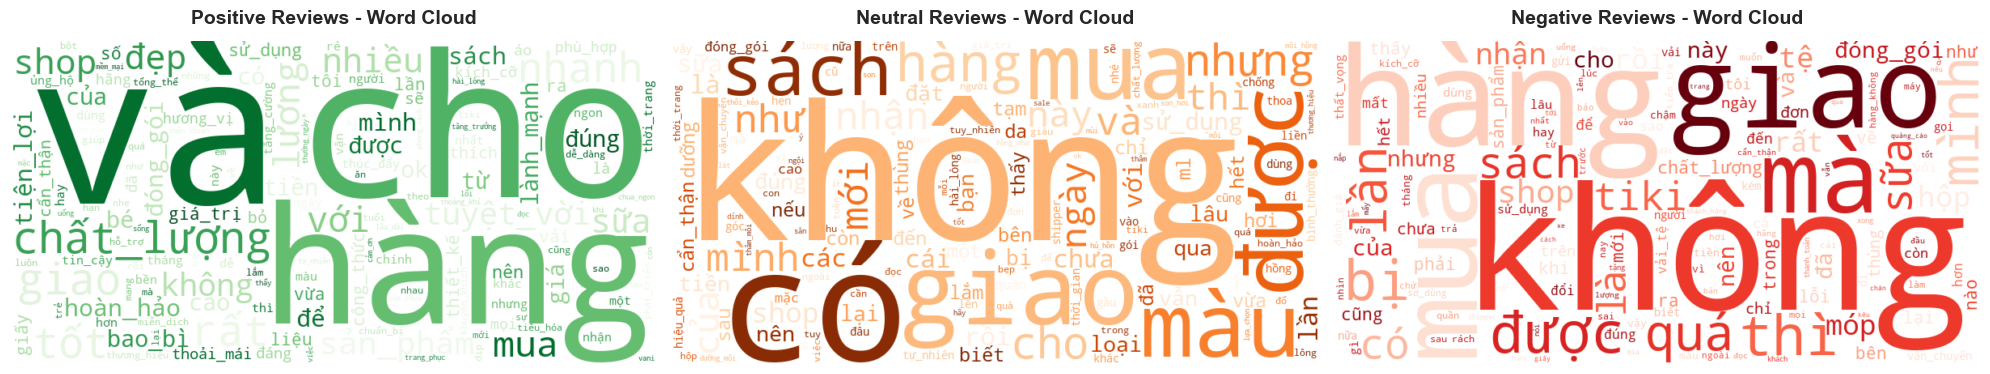

In [29]:
# Generate word clouds for positive, neutral, and negative sentiment groups
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for ax, label, colormap, title in zip(
    axes,
    ["tích cực", "trung lập", "tiêu cực"],
    ["Greens", "Oranges", "Reds"],
    ["Positive Reviews - Word Cloud", "Neutral Reviews - Word Cloud", "Negative Reviews - Word Cloud"],
):
    # Concatenate all texts in the group into a single string
    corpus = " ".join(
        df[df["sentiment_label"] == label]["cleaned_text"].astype(str)
    )

    # Initialize WordCloud with group-specific color palette
    wc = WordCloud(
        width=800, height=400,
        background_color="white",
        colormap=colormap,
        max_words=150,
        collocations=False,         # Avoid repeating phrase collocations
        prefer_horizontal=0.85,
    ).generate(corpus)

    # Display the generated image
    ax.imshow(wc, interpolation="bilinear")
    ax.set_title(title, fontsize=14, pad=12, fontweight="bold")
    ax.axis("off")

# Adjust layout to prevent overlap
plt.tight_layout()
plt.show()

**Nhận xét:**
1. **Tích cực (Xanh lá):** Nổi bật với các từ khóa mang sắc thái khen ngợi rõ ràng như *"chất_lượng"*, *"tốt"*, *"đẹp"*, *"nhanh"*. Người dùng chủ yếu bày tỏ sự hài lòng về chất lượng sản phẩm và tốc độ giao hàng.
2. **Trung lập (Cam):** Xuất hiện nhiều từ mang tính kể lể hoặc cấu trúc tương phản như *"nhưng"*, *"không"*, *"có"*. Điều này cho thấy các đánh giá trung lập thường có xu hướng khen chê lẫn lộn (ví dụ: sản phẩm ok nhưng giao chậm).
3. **Tiêu cực (Đỏ):** Bị áp đảo bởi các từ chỉ sự cố và thái độ thất vọng như *"không"*, *"bị"*, *"tệ"*, *"quá"*, *"móp"*. Khách hàng tập trung phàn nàn gay gắt về tình trạng hàng hóa bị lỗi hoặc dịch vụ tệ.

### **3.2. Top N-gram Analysis**

Trích xuất và so sánh Top 20 Unigram, Bigram, Trigram cụm từ liền kề xuất hiện thường xuyên nhất trong mỗi nhóm cảm xúc. Phân tích này giúp phát hiện ra các cụm từ thể hiện thái độ đặc thù của khách hàng (ví dụ: "giao hàng nhanh", "chất lượng kém") chứ không chỉ dừng lại ở từng từ rời rạc.

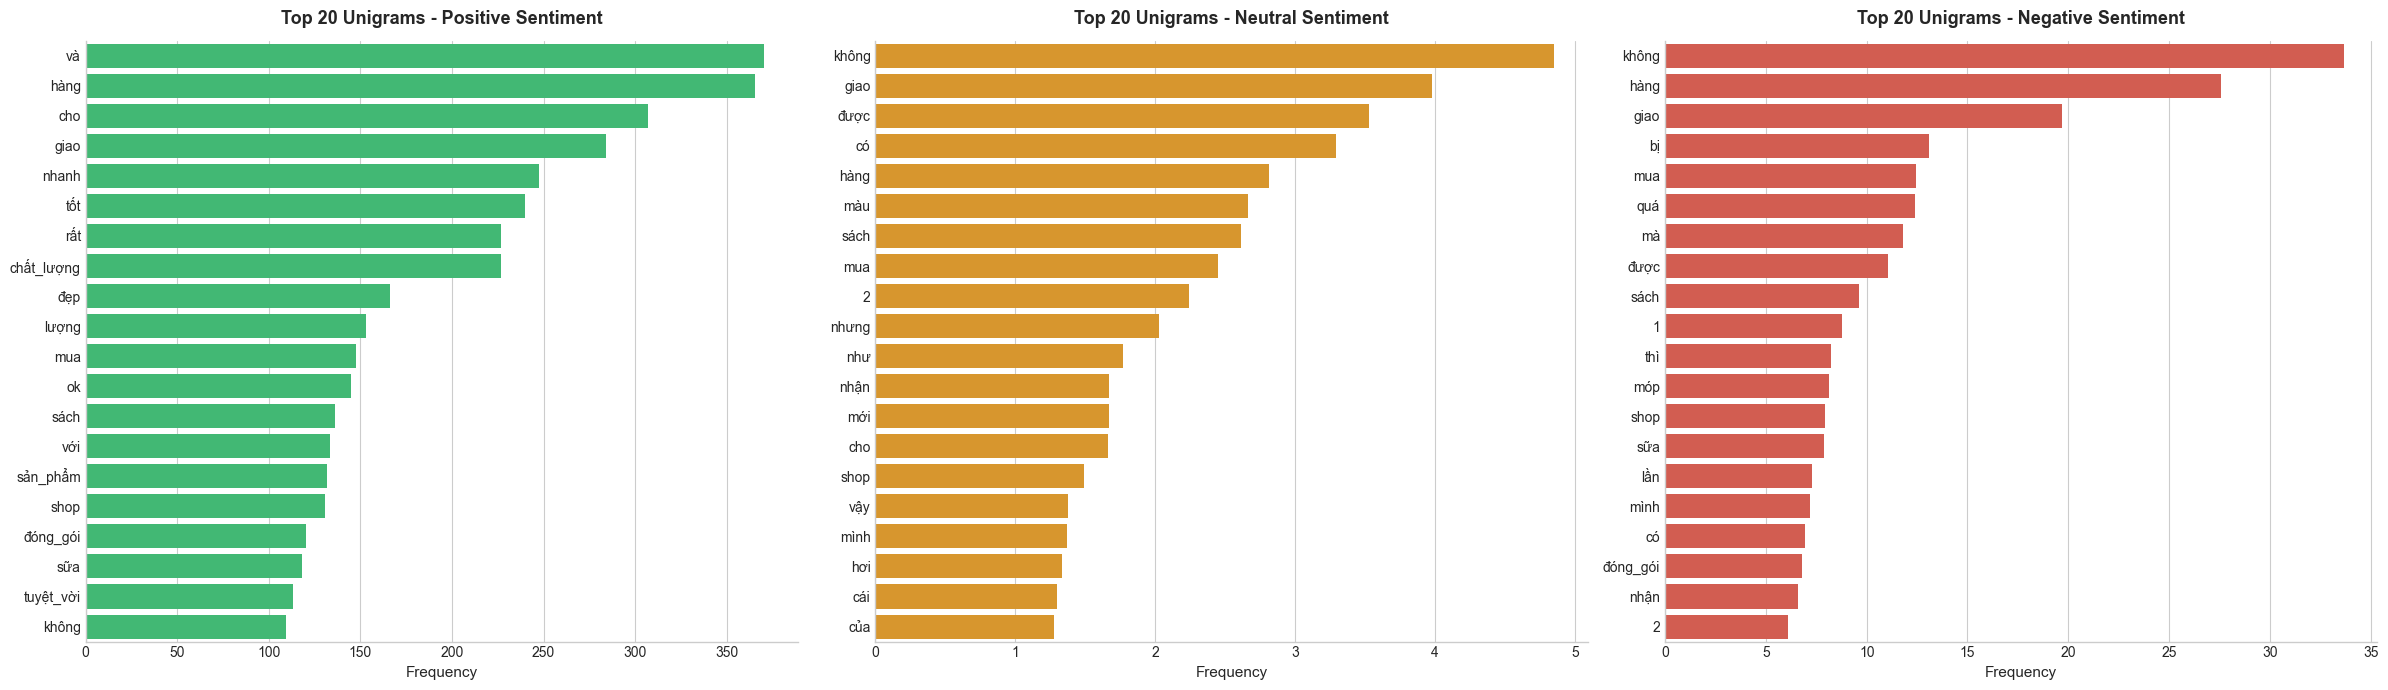

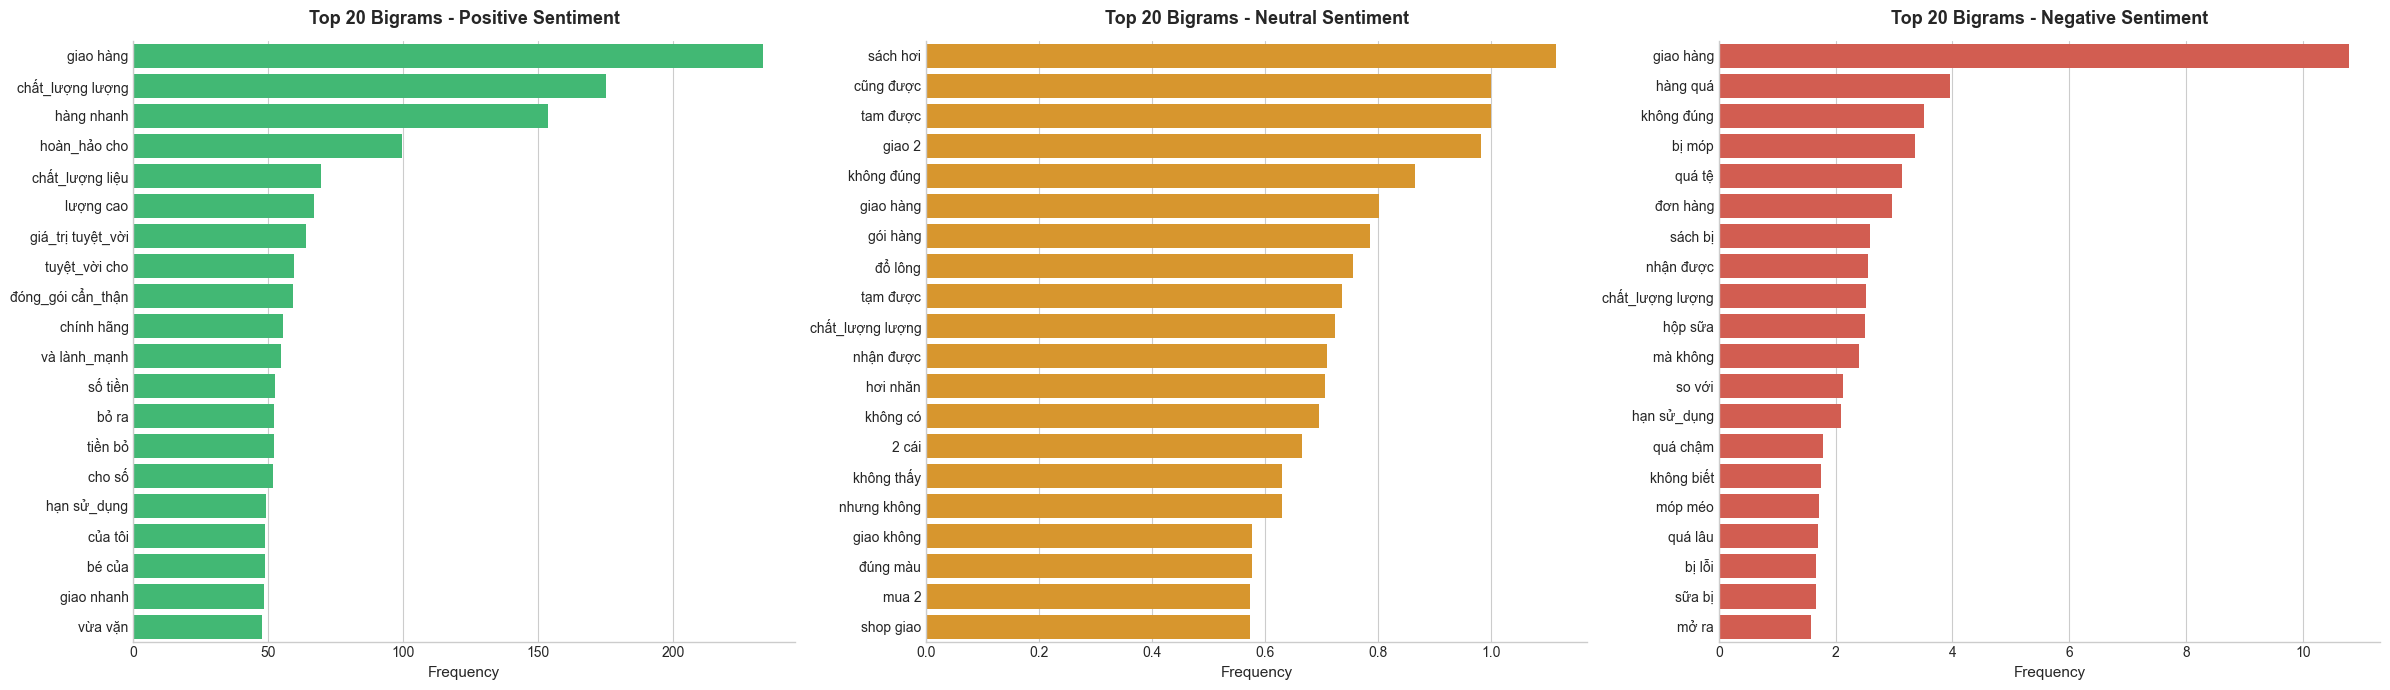

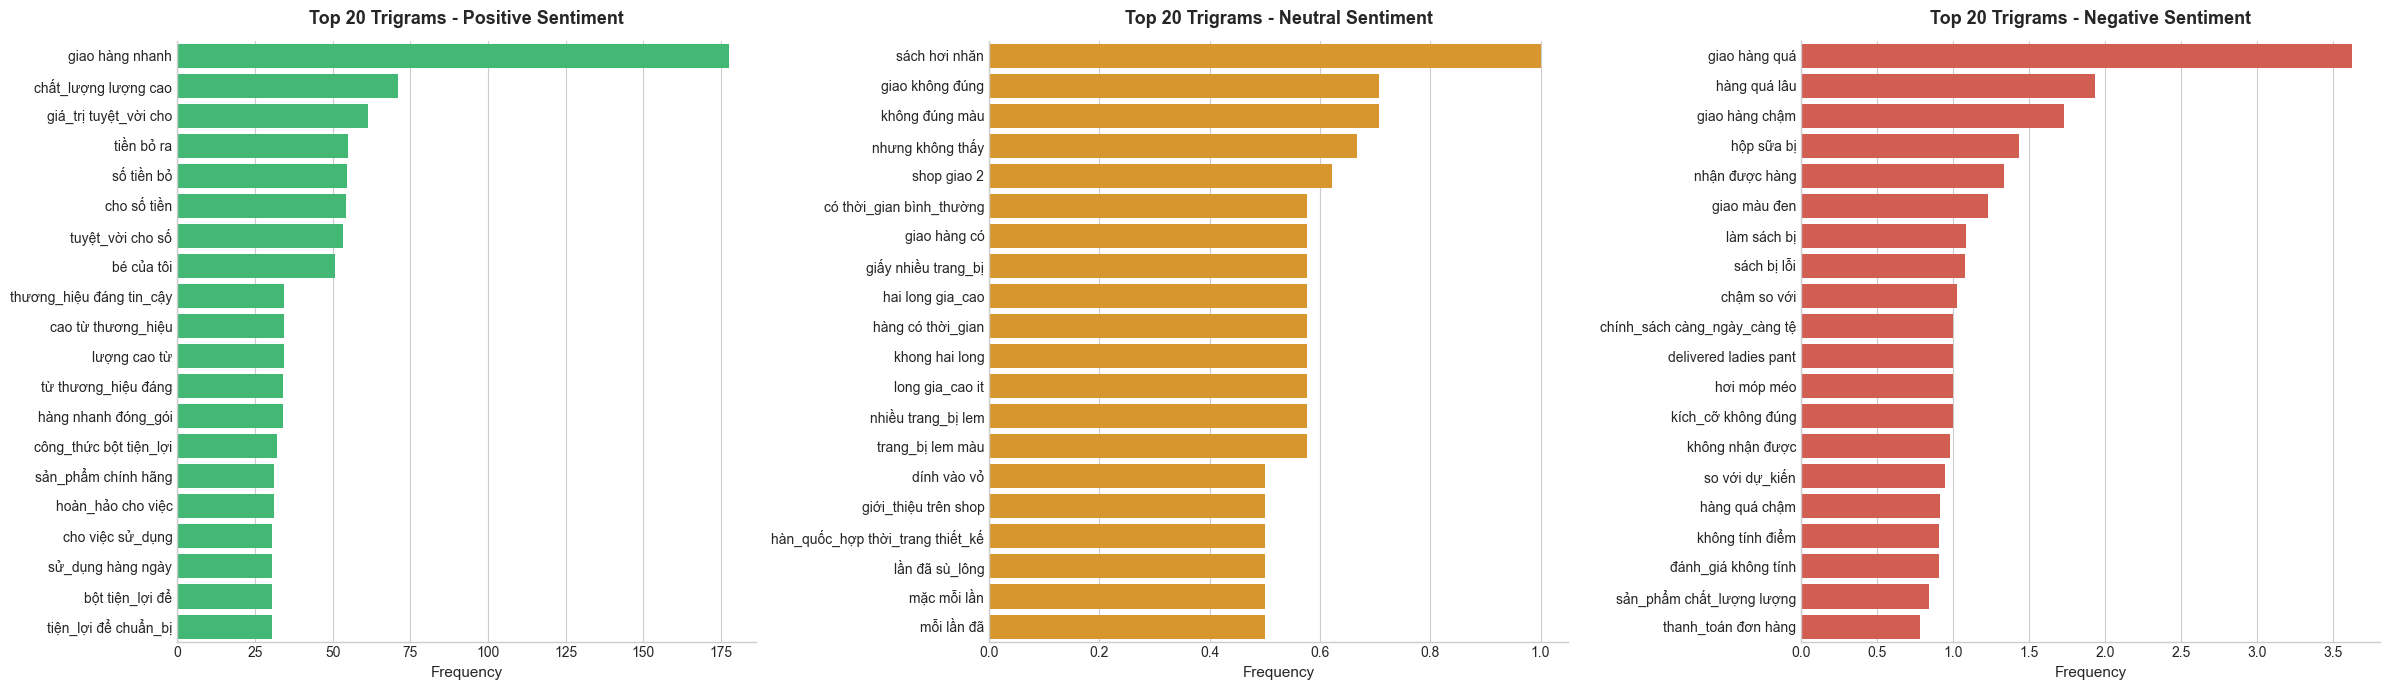

In [30]:
# Extract and compare top 20 unigrams, bigrams, and trigrams between sentiment groups

def get_top_ngrams(corpus: pd.Series, ngram_range: tuple, top_k: int = 20) -> pd.DataFrame:
    """
    Return a DataFrame of the top-k n-grams with their relative frequency (%).
    Uses TfidfVectorizer with use_idf=False for pure term frequency counting.
    """
    vec = TfidfVectorizer(
        ngram_range=ngram_range,
        max_features=10_000,
        use_idf=False,              # Count term frequency only
        token_pattern=r"(?u)\b\w+\b"
    )
    X = vec.fit_transform(corpus.fillna(""))
    freq = X.sum(axis=0).A1
    vocab = vec.get_feature_names_out()
    df_ngram = pd.DataFrame({"ngram": vocab, "count": freq})
    df_ngram = df_ngram.nlargest(top_k, "count").reset_index(drop=True)
    df_ngram["pct"] = df_ngram["count"] / df_ngram["count"].sum() * 100
    return df_ngram

# 1. Extract Unigrams, Bigrams, and Trigrams for all 3 groups
pos_corpus = df[df["sentiment_label"] == "tích cực"]["cleaned_text"]
neu_corpus = df[df["sentiment_label"] == "trung lập"]["cleaned_text"]
neg_corpus = df[df["sentiment_label"] == "tiêu cực"]["cleaned_text"]

pos_uni = get_top_ngrams(pos_corpus, (1, 1))
neu_uni = get_top_ngrams(neu_corpus, (1, 1))
neg_uni = get_top_ngrams(neg_corpus, (1, 1))

pos_bi  = get_top_ngrams(pos_corpus, (2, 2))
neu_bi  = get_top_ngrams(neu_corpus, (2, 2))
neg_bi  = get_top_ngrams(neg_corpus, (2, 2))

pos_tri = get_top_ngrams(pos_corpus, (3, 3))
neu_tri = get_top_ngrams(neu_corpus, (3, 3))
neg_tri = get_top_ngrams(neg_corpus, (3, 3))

# 2. Function to plot grouped n-grams side by side (1 row, 3 columns)
def plot_ngram_comparison(pos_data, neu_data, neg_data, ngram_name):
    # Tăng kích thước chiều ngang lên 24 để đủ không gian cho 3 biểu đồ
    fig, axes = plt.subplots(1, 3, figsize=(24, 7))
    
    # Positive Plot (Left)
    sns.barplot(x="count", y="ngram", data=pos_data, ax=axes[0], color="#2ECC71", orient="h")
    axes[0].set_title(f"Top 20 {ngram_name} - Positive Sentiment", fontsize=13, pad=12, fontweight="bold")
    axes[0].set_xlabel("Frequency", fontsize=11)
    axes[0].set_ylabel("")
    sns.despine(ax=axes[0], top=True, right=True)

    # Neutral Plot (Middle)
    sns.barplot(x="count", y="ngram", data=neu_data, ax=axes[1], color="#F39C12", orient="h")
    axes[1].set_title(f"Top 20 {ngram_name} - Neutral Sentiment", fontsize=13, pad=12, fontweight="bold")
    axes[1].set_xlabel("Frequency", fontsize=11)
    axes[1].set_ylabel("")
    sns.despine(ax=axes[1], top=True, right=True)
    
    # Negative Plot (Right)
    sns.barplot(x="count", y="ngram", data=neg_data, ax=axes[2], color="#E74C3C", orient="h")
    axes[2].set_title(f"Top 20 {ngram_name} - Negative Sentiment", fontsize=13, pad=12, fontweight="bold")
    axes[2].set_xlabel("Frequency", fontsize=11)
    axes[2].set_ylabel("")
    sns.despine(ax=axes[2], top=True, right=True)
    
    plt.tight_layout()
    plt.show()

# 3. Visualize Unigrams, Bigrams, and Trigrams 
plot_ngram_comparison(pos_uni, neu_uni, neg_uni, "Unigrams")
plot_ngram_comparison(pos_bi, neu_bi, neg_bi, "Bigrams")
plot_ngram_comparison(pos_tri, neu_tri, neg_tri, "Trigrams")

**Nhận xét:**

1. **Unigram chưa đủ ngữ cảnh:** Ở cấp độ từ đơn, cả ba nhóm đều chứa các từ chung chung như "hàng", "giao". Mặc dù nhóm tiêu cực và trung lập xuất hiện nhiều từ mang tính tương phản ("không", "bị", "nhưng"), Unigram vẫn chưa diễn tả trọn vẹn ý đồ của người viết.
2. **Bigram & Trigram làm rõ nguyên nhân:** Chuyển sang cụm 2 và 3 từ, ngữ cảnh đánh giá của khách hàng bộc lộ cực kỳ rõ nét:
   - **Tích cực:** Tập trung mạnh vào tốc độ dịch vụ (*giao hàng nhanh*) và sự thỏa mãn về sản phẩm (*chất lượng cao*, *giá trị tuyệt vời*).
   - **Trung lập:** Phản ánh thái độ chấp nhận mức độ vừa phải (*cũng được*, *tạm được*) đi kèm với những lời phàn nàn nhẹ hoặc lỗi nhỏ (*sách hơi nhăn*, *không đúng màu*, *nhưng không thấy*).
   - **Tiêu cực:** Phơi bày các điểm yếu cốt lõi làm phật lòng khách hàng, bao gồm lỗi thời gian (*giao hàng quá [lâu]*, *giao hàng chậm*) và tình trạng hỏng hóc/sai lệch hàng hóa (*bị móp*, *sách bị lỗi*, *không đúng*).
3. **Ý nghĩa cho việc trích xuất đặc trưng:** Phân tích này chứng minh rằng việc kết hợp các từ đứng cạnh nhau mang lại thông tin ngữ cảnh giá trị hơn rất nhiều so với từ đơn, đặc biệt là khả năng bắt được những sắc thái khen chê lẫn lộn tinh tế của nhóm trung lập. Do đó, việc thiết lập `ngram_range=(1, 2)` hoặc `(1, 3)` trong bộ biến đổi TF-IDF ở bước xây dựng mô hình là điều kiện bắt buộc để thu thập tối đa các tín hiệu ngữ nghĩa quan trọng này.


### **3.3. Type-Token Ratio**

Tính toán Tỷ lệ Loại/Thẻ để đo lường độ phong phú của từ vựng trong từng nhóm cảm xúc. Điểm TTR cao cho thấy cách dùng từ đa dạng, chi tiết - thường thấy khi mô tả lỗi sản phẩm; ngược lại, điểm TTR thấp phản ánh việc người dùng thường xuyên lặp lại một số khuôn mẫu quen thuộc.

In [26]:
# Compute TTR = unique word types / total tokens for each sentiment group
def compute_ttr(corpus: pd.Series) -> dict:
    """
    Compute Type-Token Ratio for a text corpus.
    High TTR indicates diverse vocabulary; low TTR indicates repetitive patterns.
    """
    all_tokens  = " ".join(corpus.astype(str)).split()
    unique_types = set(all_tokens)
    ttr = len(unique_types) / len(all_tokens) if all_tokens else 0
    return {
        "Total Tokens":  len(all_tokens),
        "Unique Types":  len(unique_types),
        "TTR":           round(ttr, 4),
    }

# Aggregate TTR results by sentiment label
ttr_results = {
    label: compute_ttr(df[df["sentiment_label"] == label]["cleaned_text"])
    for label in ["tích cực", "trung lập", "tiêu cực"]
}

ttr_df = pd.DataFrame(ttr_results).T
ttr_df.index.name = "Sentiment Label"
print("Type-Token Ratio (TTR) by Sentiment Class:")
display(ttr_df)

Type-Token Ratio (TTR) by Sentiment Class:


,Total Tokens,Unique Types,TTR
Sentiment Label,,,
tích cực,79294.0000,4441.0000,0.0560
trung lập,823.0000,385.0000,0.4678
tiêu cực,5241.0000,1088.0000,0.2076


**Nhận xét:**

1. **Sự nghèo nàn từ vựng ở nhóm tích cực:** Dù có lượng dữ liệu áp đảo hơn 79,000 tokens, nhóm tích cực lại có điểm TTR thấp nhất (0.0560). Điều này cho thấy các bình luận khen ngợi mang tính rập khuôn rất cao, người dùng thường chỉ lặp đi lặp lại một tập hợp từ vựng nhỏ quen thuộc (ví dụ: "tốt", "ok", "đẹp", "nhanh").
2. **Sự đa dạng ở nhóm tiêu cực:** Nhóm tiêu cực có tỷ lệ TTR cao hơn đáng kể (0.2076). Khi không hài lòng, khách hàng có xu hướng sử dụng ngôn từ phong phú, chi tiết và đa dạng hơn để phàn nàn và mô tả chính xác lỗi họ gặp phải.
3. **Ảnh hưởng của kích thước tập dữ liệu:** Nhóm trung lập có điểm TTR cao nhất (0.4678), tuy nhiên điều này phần lớn là do hiện tượng thống kê - định luật Heap: tập dữ liệu càng nhỏ ở đây chỉ có 823 tokens thì tỷ lệ TTR tự nhiên sẽ càng cao. Do đó, điểm số của nhóm này chỉ mang tính chất tham khảo.


### **3.4. Zipf's Law Verification**

Kiểm chứng Định luật Zipf bằng biểu đồ log-log giữa thứ hạng và tần suất xuất hiện của từ vựng. Bước này giúp đánh giá tỷ lệ nhiễu, từ hiếm, biệt ngữ hoặc lỗi chính tả, từ đó đưa ra quyết định thiết lập các ngưỡng cắt tỉa (ví dụ: `min_df`) khi xây dựng bộ véc-tơ đặc trưng ở các bước sau.


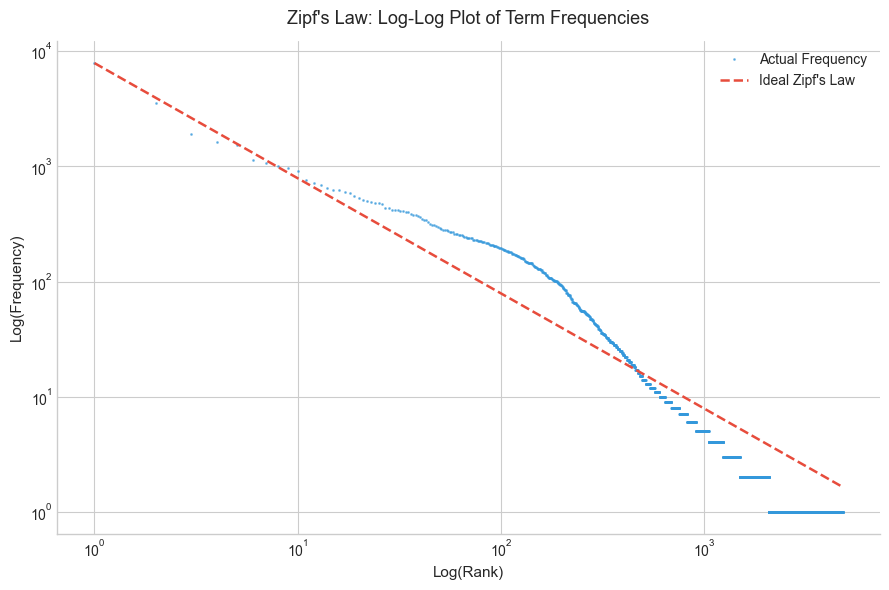

Total vocabulary size : 4,804 unique tokens
Top-1 word frequency  : 7,891 occurrences
Hapax Legomena (freq=1): 2,721 tokens (56.6%)


In [31]:
# Verify Zipf's Law on the full corpus using a log-log plot
all_words   = " ".join(df["cleaned_text"].astype(str)).split()
word_freq   = Counter(all_words)

# Sort by descending frequency to assign rank
frequencies = sorted(word_freq.values(), reverse=True)
ranks       = np.arange(1, len(frequencies) + 1)

# Compute ideal Zipf line: freq proportional to 1/rank -> log(freq) = -log(rank) + const
zipf_ideal = frequencies[0] / ranks   # anchored at rank-1

fig, ax = plt.subplots(figsize=(9, 6))

# Observed frequency curve
ax.loglog(ranks, frequencies, marker=".", markersize=2,
          color="#3498db", linewidth=0, alpha=0.6, label="Actual Frequency")

# Ideal Zipf reference line
ax.loglog(ranks, zipf_ideal, color="#E74C3C", linewidth=1.8,
          linestyle="--", label="Ideal Zipf's Law")

ax.set_title("Zipf's Law: Log-Log Plot of Term Frequencies", fontsize=13, pad=12)
ax.set_xlabel("Log(Rank)",      fontsize=11)
ax.set_ylabel("Log(Frequency)", fontsize=11)
ax.legend(frameon=False, fontsize=10)
sns.despine(ax=ax, top=True, right=True)
plt.tight_layout()
plt.show()

# Print vocabulary summary statistics
print(f"Total vocabulary size : {len(word_freq):,} unique tokens")
print(f"Top-1 word frequency  : {frequencies[0]:,} occurrences")
print(f"Hapax Legomena (freq=1): {sum(1 for f in frequencies if f == 1):,} tokens "
      f"({sum(1 for f in frequencies if f == 1)/len(frequencies)*100:.1f}%)")

**Nhận xét:**

1. **Tính tự nhiên của dữ liệu:** Đường màu xanh bám khá sát đường màu đỏ ở phần đầu. Điều này chứng tỏ tập dữ liệu review của chúng ta tuân thủ đúng quy luật tự nhiên của ngôn ngữ con người, không phải văn bản được tạo ra một cách ngẫu nhiên hay bị lỗi nhiễu nghiêm trọng.
2. **Hiện tượng phình to ở đoạn giữa:** Từ mốc hạng 10 đến 100, đường màu xanh hơi vồng lên trên đường lý thuyết. Đây là đặc trưng của dữ liệu chuyên ngành: khách hàng có xu hướng lặp lại một nhóm từ vựng thương mại nhất định ("giao", "hàng", "chất_lượng", "shop") với tần suất cao hơn bình thường so với ngôn ngữ giao tiếp tổng quát.
3. **Phần đuôi gãy gập:** Ở phần cuối (bên phải), đường màu xanh tụt dốc nhanh và tạo thành các bậc thang. Đây là tập hợp của hàng nghìn từ rất hiếm gặp chỉ xuất hiện 1-2 lần, thường là lỗi chính tả, từ viết tắt dị thường hoặc tên sản phẩm đặc thù. 
4. **Hành động:** 
   - Phần đầu quá phổ biến dễ gây nhiễu -> Khẳng định sức mạnh của thuật toán TF-IDF sẽ giúp giảm trọng số của các từ này.
   - Phần đuôi quá hiếm gặp sẽ làm ma trận TF-IDF bị phình to vô ích -> Bắt buộc phải thiết lập tham số `min_df` loại bỏ từ hiếm hoặc `max_features` khi vector hóa dữ liệu.


---
## **4. Sparse Feature Representation (TF-IDF)**

Biểu diễn thưa thông qua TF-IDF là tiêu chuẩn kinh điển trong xử lý ngôn ngữ tự nhiên. Phương pháp này biến đổi văn bản thành không gian véc-tơ dựa trên tần suất xuất hiện tương đối của N-gram, đồng thời giảm trọng số các từ xuất hiện quá phổ biến trong tập ngữ liệu. Ma trận TF-IDF có dạng `[n_documents × n_features]` với phần lớn các phần tử bằng 0.

**Phương pháp đánh giá không gian TF-IDF:**
1. Định lượng số chiều và tỉ lệ thưa thớt của ma trận.
2. Áp dụng t-SNE để chiếu xuống 2D và trực quan hóa khả năng phân cụm.
3. Tính điểm Silhouette để đo lường mức độ tách biệt hình học giữa các lớp.
4. Huấn luyện LinearSVC làm mô hình cơ sở để đánh giá khả năng phân loại.


### **4.1. TF-IDF Vectorization**

Khởi tạo và huấn luyện mô hình TF-IDF Vectorizer để chuyển đổi tập văn bản thành ma trận đặc trưng thưa. Ở bước này, chúng ta đồng thời kiểm soát số chiều không gian đặc trưng và loại bỏ các từ nhiễu hiếm gặp thông qua các tham số `min_df` và `max_features`.


In [35]:
# Initialize TF-IDF vectorizer
tfidf_vectorizer = TfidfVectorizer(
    ngram_range=(1, 2),
    max_features=8000,
    min_df=3,
    sublinear_tf=True,
    token_pattern=r"(?u)\b\w+\b"
)

# Fit + transform
X_tfidf = tfidf_vectorizer.fit_transform(df["cleaned_text"].fillna(""))
y_labels = df["sentiment_label"].values

# Compute sparsity
total_elements = X_tfidf.shape[0] * X_tfidf.shape[1]
nonzero_count  = X_tfidf.nnz
sparsity_ratio = (1 - nonzero_count / total_elements) * 100

# Create summary table 
matrix_info = pd.DataFrame({
    "Property": [
        "Matrix Shape (Docs x Features)",
        "Non-zero Elements",
        "Sparsity Ratio",
        "Memory Usage (MB)",
    ],
    "Value": [
        f"{X_tfidf.shape[0]:,} x {X_tfidf.shape[1]:,}",
        f"{nonzero_count:,}",
        f"{sparsity_ratio:.2f} %",
        f"{X_tfidf.data.nbytes / 1e6:.2f} MB",
    ]
})

print("TF-IDF Matrix Properties:")
display(matrix_info)

TF-IDF Matrix Properties:


,Property,Value
0,Matrix Shape (Docs x Features),"4,651 x 4,408"
1,Non-zero Elements,"102,320"
2,Sparsity Ratio,99.50 %
3,Memory Usage (MB),0.82 MB


### **4.2. t-SNE Visualization**

Áp dụng thuật toán giảm chiều t-SNE để chiếu không gian TF-IDF xuống mặt phẳng 2D. Bước này giúp chúng ta trực quan hóa hình học và đánh giá xem các nhóm cảm xúc có thực sự phân tách biệt lập hay không.

Running t-SNE on 4,651 samples - this may take a moment...
t-SNE completed.


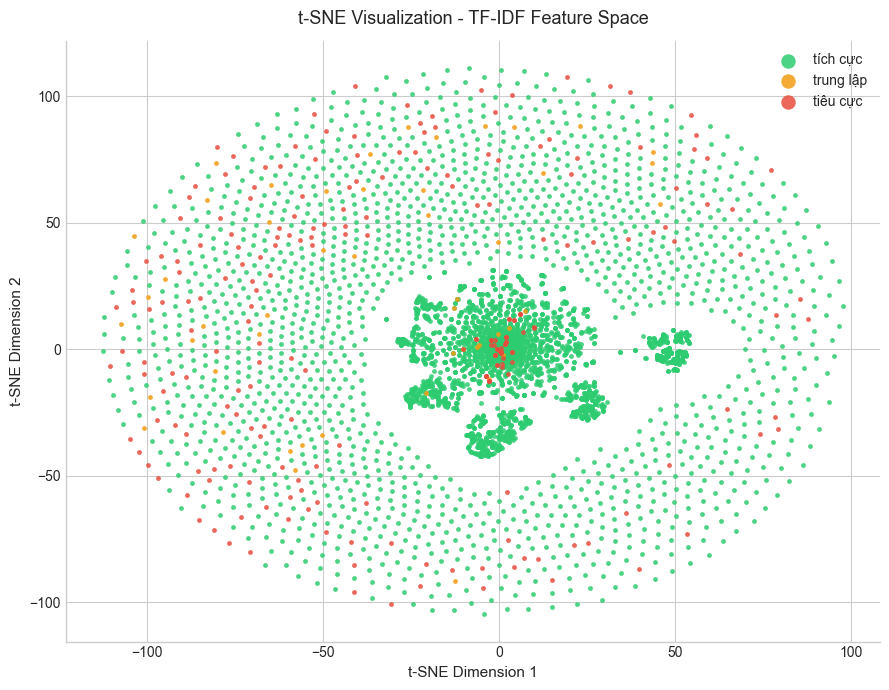

In [39]:
# Subsample for t-SNE to keep runtime reasonable
# (t-SNE has O(N^2) complexity -- slow on large datasets)
N_SAMPLE = len(df)
sample_idx = np.random.RandomState(SEED).choice(len(df), N_SAMPLE, replace=False)

X_tfidf_sample  = X_tfidf[sample_idx].toarray()
y_sample        = y_labels[sample_idx]

# Apply t-SNE to project TF-IDF space down to 2 dimensions
print(f"Running t-SNE on {N_SAMPLE:,} samples - this may take a moment...")
tsne = TSNE(
    n_components=2,
    perplexity=40,
    max_iter=1_000,
    learning_rate="auto",
    init="pca",
    random_state=SEED,
    n_jobs=-1,
)
X_tfidf_2d = tsne.fit_transform(X_tfidf_sample)
print("t-SNE completed.")

# Scatter plot of t-SNE projection colored by sentiment label
fig, ax = plt.subplots(figsize=(9, 7))
palette_map = {"tích cực": "#2ECC71", "trung lập": "#F39C12", "tiêu cực": "#E74C3C"}

for label, color in palette_map.items():
    mask = y_sample == label
    ax.scatter(
        X_tfidf_2d[mask, 0], X_tfidf_2d[mask, 1],
        c=color, 
        label=label, 
        alpha=0.85,         
        s=12,                
        linewidths=0,
    )

ax.set_title("t-SNE Visualization - TF-IDF Feature Space", fontsize=13, pad=12)
ax.set_xlabel("t-SNE Dimension 1", fontsize=11)
ax.set_ylabel("t-SNE Dimension 2", fontsize=11)
ax.legend(markerscale=3, frameon=False, fontsize=10)
sns.despine(ax=ax, top=True, right=True)
plt.tight_layout()
plt.show()


**Nhận xét biểu đồ t-SNE:**

1. **Áp đảo bởi dữ liệu mất cân bằng:** Có thể thấy rõ lớp tích cực (màu xanh lá) chiếm số lượng áp đảo và phủ kín gần như toàn bộ không gian phân phối, phản ánh đúng tình trạng mất cân bằng nhãn của tập dữ liệu gốc.
2. **Sự chồng lấp ranh giới phân loại:** Các điểm tiêu cực (màu đỏ) và trung lập (màu cam) phân tán rải rác và trộn lẫn mạnh vào đám mây điểm tích cực. Chúng không tạo thành các cụm độc lập, riêng biệt.
3. **Hạn chế của không gian TF-IDF:** Sự chồng lấp này cho thấy biểu diễn TF-IDF chủ yếu gom nhóm dựa trên sự xuất hiện của các từ vựng chung chung bề mặt (như *hàng, giao, shop...*) mà chưa tách bạch được sắc thái ngữ nghĩa sâu xa. Điều này dự báo rằng các mô hình phân loại tuyến tính cơ bản sẽ gặp khó khăn trong việc vẽ ra ranh giới quyết định chính xác và dễ đưa ra dự đoán sai đối với nhóm thiểu số.


### **4.3. Silhouette Score & Baseline Classification**

Đánh giá chất lượng của biểu diễn TF-IDF thông qua điểm số Silhouette và độ chính xác của mô hình phân loại tuyến tính cơ bằng phương pháp kiểm chứng chéo.

In [42]:
# Encode string labels to integers for sklearn compatibility
le = LabelEncoder()
y_encoded        = le.fit_transform(y_labels)
y_sample_encoded = le.transform(y_sample)

# Compute Silhouette Score on the 2D t-SNE projection (fast geometry check)
# Silhouette in [-1, 1]: higher values indicate better-separated clusters
sil_tfidf = silhouette_score(X_tfidf_2d, y_sample_encoded, random_state=SEED)
print(f"TF-IDF t-SNE Silhouette Score: {sil_tfidf:.4f}")

# Train LinearSVC baseline with 5-fold Cross-Validation
# class_weight='balanced' handles label imbalance
print("\nRunning 5-fold CV with LinearSVC on TF-IDF features...")
svc_tfidf = LinearSVC(class_weight="balanced", max_iter=2_000, random_state=SEED)
cv_scores_tfidf = cross_val_score(
    svc_tfidf, X_tfidf, y_encoded,
    cv=5, scoring="f1_macro", n_jobs=-1,
)

# Summarize TF-IDF baseline results
tfidf_eval = pd.DataFrame({
    "Metric": [
        "t-SNE Silhouette Score",
        "LinearSVC Macro F1 (Mean)",
        "LinearSVC Macro F1 (Std)",
        "LinearSVC Macro F1 (Min)",
        "LinearSVC Macro F1 (Max)",
    ],
    "TF-IDF": [
        f"{sil_tfidf:.4f}",
        f"{cv_scores_tfidf.mean():.4f}",
        f"+/- {cv_scores_tfidf.std():.4f}",
        f"{cv_scores_tfidf.min():.4f}",
        f"{cv_scores_tfidf.max():.4f}",
    ]
}).reset_index(drop=True)

print("\nTF-IDF Baseline Evaluation Summary:")
display(tfidf_eval)

TF-IDF t-SNE Silhouette Score: 0.1829

Running 5-fold CV with LinearSVC on TF-IDF features...

TF-IDF Baseline Evaluation Summary:


,Metric,TF-IDF
0,t-SNE Silhouette Score,0.1829
1,LinearSVC Macro F1 (Mean),0.5061
2,LinearSVC Macro F1 (Std),+/- 0.0232
3,LinearSVC Macro F1 (Min),0.4613
4,LinearSVC Macro F1 (Max),0.5235


**Nhận xét kết quả Baseline TF-IDF:**

1. **Phân tách không gian kém:** Điểm Silhouette rất thấp xác nhận lại quan sát từ biểu đồ t-SNE: các điểm dữ liệu trong không gian TF-IDF bị chồng lấp nặng nề, ranh giới giữa các cụm cảm xúc không hề rõ ràng.
2. **Hiệu suất phân loại thấp:** Điểm số trung bình Macro F1 chỉ đạt khoảng 50.6% cho thấy mô hình LinearSVC dự đoán rất kém trên các nhóm thiểu số (tiêu cực, trung lập). Mặc dù đã dùng trọng số cân bằng (`class_weight='balanced'`), TF-IDF vẫn không cung cấp đủ thông tin ngữ nghĩa để mô hình phân loại chính xác.
3. **Kết luận:** Đặc trưng đếm từ khóa và mô hình tuyến tính là chưa đủ để giải quyết bài toán phân loại cảm xúc có độ phức tạp cao và mất cân bằng nhãn này. Chúng ta cần một phương pháp biểu diễn ngôn ngữ sâu hơn ở bước tiếp theo.


---
## **5. Dense Semantic Representation (Sentence Transformers)**

Trái ngược với TF-IDF — phương pháp vô tình phá vỡ cấu trúc ngữ pháp và bỏ qua ngữ nghĩa sâu thông qua các mô hình ngôn ngữ lớn như Sentence-BERT (`keepitreal/vietnamese-sbert`) mã hóa văn bản thành các véc-tơ không gian có số chiều cố định nhưng chứa đựng độ nén thông tin cực cao.

Trong không gian này, các câu có ý nghĩa tương đồng sẽ có khoảng cách hình học gần nhau, bất chấp việc chúng không dùng chung một từ vựng nào. Ví dụ: `"Hàng chất"` và `"Sản phẩm tốt"` sẽ nằm gần nhau trong không gian D nhưng hoàn toàn không liên quan trong không gian TF-IDF.

**Mục tiêu phần này:**
1. Mã hóa toàn bộ văn bản thành Dense Embeddings bằng `keepitreal/vietnamese-sbert`.
2. Áp dụng t-SNE để trực quan hóa và so sánh với không gian TF-IDF.
3. Kiểm định bằng K-Means clustering để đánh giá cấu trúc tự nhiên của không gian nhúng.
4. So sánh Silhouette Score và Baseline Macro F1 giữa TF-IDF và SBERT.


### **5.1. Encoding with Vietnamese SBERT**

Sử dụng mô hình ngôn ngữ chuyên dụng cho tiếng Việt (`vietnamese-sbert`) để mã hóa các bình luận thành vector ngữ nghĩa dày đặc. Khác với TF-IDF chỉ đếm từ khóa, SBERT có khả năng hiể" được ngữ cảnh và sự tương đồng ý nghĩa giữa các câu dù chúng dùng từ vựng hoàn toàn khác nhau.

In [43]:
# Load the Vietnamese SBERT model fine-tuned on Vietnamese data
print("Loading vietnamese-sbert model...")
sbert_model = SentenceTransformer("keepitreal/vietnamese-sbert")

# Encode the full text corpus into dense embeddings
# show_progress_bar=True: display progress when encoding large datasets
print("Encoding corpus into dense embeddings...")
X_dense = sbert_model.encode(
    df["cleaned_text"].fillna("").tolist(),
    batch_size=64,
    show_progress_bar=True,
    convert_to_numpy=True,
)

print(f"\nDense Embedding Matrix Shape: {X_dense.shape}")
print(f"  {X_dense.shape[0]:,} documents x {X_dense.shape[1]} dimensions")
print(f"  Memory usage: {X_dense.nbytes / 1e6:.1f} MB")

Loading vietnamese-sbert model...


c:\Users\ADMIN\AppData\Local\Programs\Python\Python312\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\ADMIN\.cache\huggingface\hub\models--keepitreal--vietnamese-sbert. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


Encoding corpus into dense embeddings...


Batches: 100%|██████████| 73/73 [03:18<00:00,  2.72s/it]


Dense Embedding Matrix Shape: (4651, 768)
  4,651 documents x 768 dimensions
  Memory usage: 14.3 MB


### **5.2. t-SNE Visualization — Dense Space**

Áp dụng t-SNE để giảm chiều không gian Dense và vẽ biểu đồ. Việc đặt cạnh biểu đồ của TF-IDF sẽ giúp chúng ta so sánh trực quan xem SBERT có thực sự kéo các bình luận cùng cảm xúc lại gần nhau và tách biệt các nhóm tốt hơn hay không.


Running t-SNE on Dense Embeddings (4,651 samples)...
t-SNE on Dense Embeddings completed.


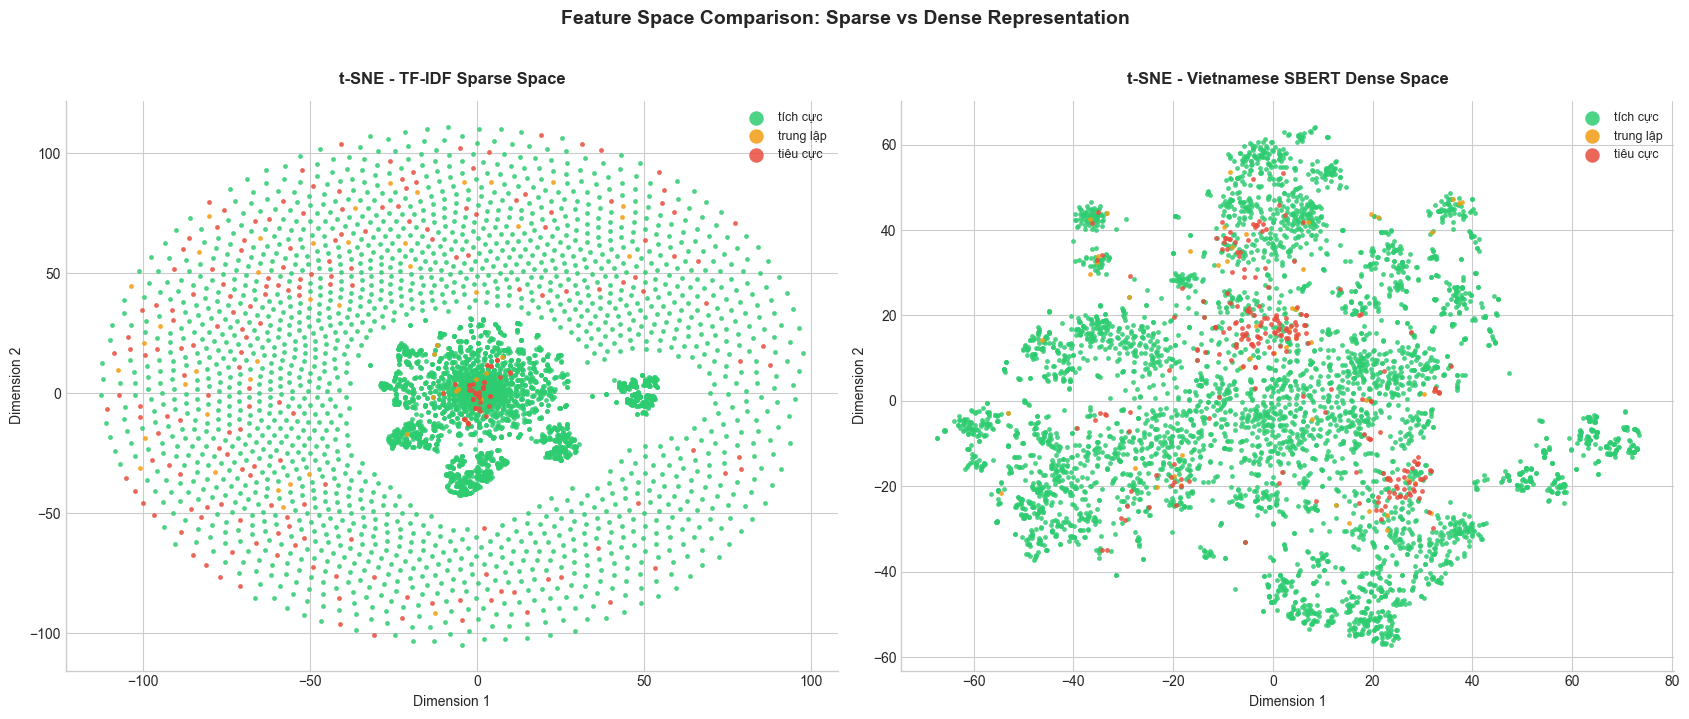

In [46]:
# Use the same sample indices as the TF-IDF t-SNE step for a fair comparison
X_dense_sample = X_dense[sample_idx]

# Apply t-SNE to the Dense space (768 -> 2 dimensions)
print(f"Running t-SNE on Dense Embeddings ({N_SAMPLE:,} samples)...")
X_dense_2d = tsne.fit_transform(X_dense_sample)
print("t-SNE on Dense Embeddings completed.")

# Side-by-side t-SNE comparison: TF-IDF (left) vs Dense SBERT (right)
fig, axes = plt.subplots(1, 2, figsize=(17, 7))

for ax, X_2d, title in zip(
    axes,
    [X_tfidf_2d, X_dense_2d],
    ["t-SNE - TF-IDF Sparse Space", "t-SNE - Vietnamese SBERT Dense Space"],
):
    for label, color in palette_map.items():
        mask = y_sample == label
        ax.scatter(
            X_2d[mask, 0], X_2d[mask, 1],
            c=color, 
            label=label, 
            alpha=0.85,        
            s=12,             
            linewidths=0,
        )
    ax.set_title(title, fontsize=12, pad=12, fontweight="bold")
    ax.set_xlabel("Dimension 1", fontsize=10)
    ax.set_ylabel("Dimension 2", fontsize=10)
    ax.legend(markerscale=3, frameon=False, fontsize=9)
    sns.despine(ax=ax, top=True, right=True)

plt.suptitle("Feature Space Comparison: Sparse vs Dense Representation",
             fontsize=14, y=1.02, fontweight="bold")
plt.tight_layout()
plt.show()


**Nhận xét so sánh không gian đặc trưng:**

1. **Hình thái phân bố:** Biểu đồ TF-IDF bên trái tạo ra một cấu trúc hình khuyên rất nhân tạo với một lõi đặc và viền thưa — đây là hiện tượng ảo ảnh điển hình khi chạy t-SNE trên dữ liệu quá thưa thớt. Ngược lại, không gian SBERT bên phải phân bổ một cách tự nhiên và hữu cơ hơn, hình thành nên nhiều cụm nhỏ mang ý nghĩa.
2. **Khả năng gom nhóm:** Ở không gian TF-IDF, các điểm tiêu cực (màu đỏ) và trung lập (màu cam) bị rải rác ngẫu nhiên khắp mọi nơi. Nhưng khi chuyển sang không gian Dense của SBERT, các điểm tiêu cực đã bắt đầu có xu hướng co cụm lại với nhau tại một số khu vực cục bộ nhất định (ví dụ: khu vực trung tâm và góc dưới).
3. **Kết luận trực quan:** Dù vẫn còn sự chồng lấp do đặc thù dữ liệu bị mất cân bằng quá nặng, biểu đồ chứng minh rõ ràng rằng mô hình ngôn ngữ SBERT đã bắt được các nét tương đồng về ngữ nghĩa sâu xa, kéo các bình luận tiêu cực lại gần nhau hơn hẳn so với phương pháp đếm từ khóa thô sơ của TF-IDF.


### **5.3. Unsupervised K-Means Clustering Test**

Thử nghiệm thuật toán gom cụm K-Means (k=3) hoàn toàn không giám sát, không dùng đến nhãn cảm xúc. Phép thử này nhằm trả lời câu hỏi: *"Liệu không gian ngữ nghĩa của SBERT có cấu trúc tốt đến mức tự nó hình thành nên 3 cụm tự nhiên (tích cực, tiêu cực, trung lập) mà không cần AI biết trước nhãn hay không?"*

K-Means (k=3) Silhouette Score on Dense Space: 0.0649


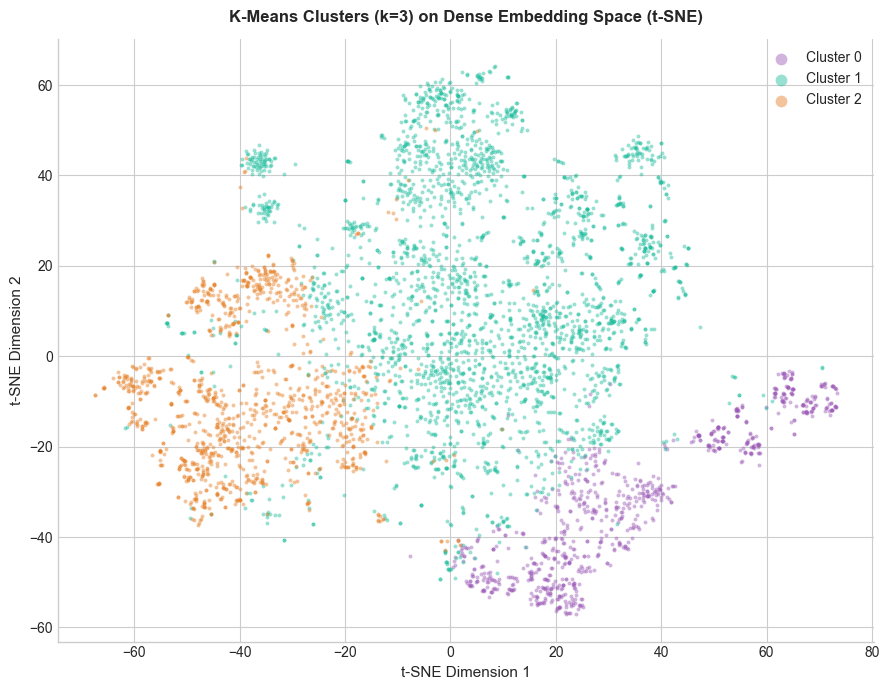

In [45]:
# Fully unsupervised test: K-Means with k=3 (matching the 3 sentiment labels)
# Goal: check whether the Dense space has natural cluster structure without labels
kmeans = KMeans(n_clusters=3, n_init=20, random_state=SEED)
cluster_labels_dense = kmeans.fit_predict(X_dense_sample)

# Silhouette Score for K-Means clustering in the Dense space
sil_kmeans_dense = silhouette_score(X_dense_sample, cluster_labels_dense)
print(f"K-Means (k=3) Silhouette Score on Dense Space: {sil_kmeans_dense:.4f}")

# Overlay K-Means cluster assignments on the t-SNE plot
fig, ax = plt.subplots(figsize=(9, 7))
cluster_palette = ["#9B59B6", "#1ABC9C", "#E67E22"]

for cid, color in enumerate(cluster_palette):
    mask = cluster_labels_dense == cid
    ax.scatter(
        X_dense_2d[mask, 0], X_dense_2d[mask, 1],
        c=color, label=f"Cluster {cid}", alpha=0.45, s=8, linewidths=0,
    )

ax.set_title("K-Means Clusters (k=3) on Dense Embedding Space (t-SNE)",
             fontsize=12, pad=12, fontweight="bold")
ax.set_xlabel("t-SNE Dimension 1", fontsize=11)
ax.set_ylabel("t-SNE Dimension 2", fontsize=11)
ax.legend(markerscale=3, frameon=False, fontsize=10)
sns.despine(ax=ax, top=True, right=True)
plt.tight_layout()
plt.show()

**Nhận xét K-Means:**

1. **Phân cụm rõ nét:** Dù không được cung cấp nhãn, K-Means vẫn tự động chia cắt không gian SBERT thành 3 cụm hình học tách biệt.
2. **Gom cụm theo chủ đề:** Do 94% dữ liệu là tích cực, 3 cụm này không đại diện cho 3 nhãn cảm xúc, mà đại diện cho 3 chủ đề ngữ nghĩa tự nhiên trong đánh giá của khách (ví dụ: khen giao hàng, khen sản phẩm, phàn nàn).
3. **Ưu điểm của SBERT:** Biểu đồ chứng tỏ SBERT có cấu trúc toán học chặt chẽ và khả năng hiểu ngữ nghĩa sâu xa vượt trội hơn hẳn TF-IDF, rất phù hợp để dùng cho Deep Learning.


### **5.4. Baseline Classification Comparison**

Huấn luyện lại mô hình LinearSVC cơ sở trên đặc trưng SBERT mới tạo và xuất bảng so sánh toàn diện với TF-IDF. Bước này cung cấp bằng chứng định lượng thông qua điểm Silhouette và Macro F1 để đi đến kết luận cuối cùng: Việc sử dụng biểu diễn ngữ nghĩa sâu có thực sự mang lại sự vượt trội đáng kể để bào chữa cho chi phí tính toán cao hơn hay không.

In [47]:
# Train LinearSVC on Dense Embeddings with 5-fold CV
print("Running 5-fold CV with LinearSVC on Dense SBERT features...")
svc_dense = LinearSVC(class_weight="balanced", max_iter=2_000, random_state=SEED)
cv_scores_dense = cross_val_score(
    svc_dense, X_dense, y_encoded,
    cv=5, scoring="f1_macro", n_jobs=-1,
)
print("Done.")

# Compute Silhouette Score on the Dense 2D t-SNE projection
sil_dense = silhouette_score(X_dense_2d, y_sample_encoded, random_state=SEED)

# Comprehensive comparison table: TF-IDF vs Dense SBERT
comparison_df = pd.DataFrame({
    "Metric": [
        "t-SNE Silhouette Score",
        "LinearSVC Macro F1 (Mean +/- Std)",
        "LinearSVC Macro F1 (Min)",
        "LinearSVC Macro F1 (Max)",
        "Feature Dimensionality",
        "Matrix Density",
    ],
    "TF-IDF (Sparse)": [
        f"{sil_tfidf:.4f}",
        f"{cv_scores_tfidf.mean():.4f} +/- {cv_scores_tfidf.std():.4f}",
        f"{cv_scores_tfidf.min():.4f}",
        f"{cv_scores_tfidf.max():.4f}",
        f"{X_tfidf.shape[1]:,} features",
        f"{(1 - sparsity_ratio/100)*100:.2f}% non-zero",
    ],
    "Vietnamese SBERT (Dense)": [
        f"{sil_dense:.4f}",
        f"{cv_scores_dense.mean():.4f} +/- {cv_scores_dense.std():.4f}",
        f"{cv_scores_dense.min():.4f}",
        f"{cv_scores_dense.max():.4f}",
        f"{X_dense.shape[1]} dimensions",
        "100% (dense vector)",
    ],
}).set_index("Metric")

print("\nFeature Representation Comparison Summary:")
display(comparison_df)

Running 5-fold CV with LinearSVC on Dense SBERT features...
Done.

Feature Representation Comparison Summary:


,TF-IDF (Sparse),Vietnamese SBERT (Dense)
Metric,,
t-SNE Silhouette Score,0.1829,-0.1309
LinearSVC Macro F1 (Mean +/- Std),0.5061 +/- 0.0232,0.5052 +/- 0.0410
LinearSVC Macro F1 (Min),0.4613,0.4470
LinearSVC Macro F1 (Max),0.5235,0.5704
Feature Dimensionality,"4,408 features",768 dimensions
Matrix Density,0.50% non-zero,100% (dense vector)


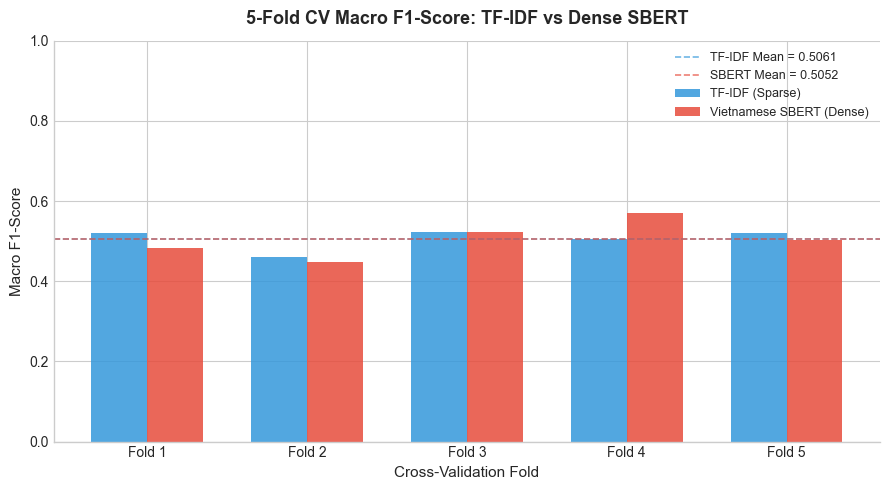

In [49]:
# Visualize Macro F1 comparison between TF-IDF and Dense SBERT
fig, ax = plt.subplots(figsize=(9, 5))

x = np.arange(5)
width = 0.35

bars1 = ax.bar(x - width/2, cv_scores_tfidf, width,
               color="#3498DB", alpha=0.85, label="TF-IDF (Sparse)")
bars2 = ax.bar(x + width/2, cv_scores_dense, width,
               color="#E74C3C", alpha=0.85, label="Vietnamese SBERT (Dense)")

# Mean reference lines
ax.axhline(cv_scores_tfidf.mean(), color="#3498DB", linestyle="--",
           linewidth=1.2, alpha=0.7, label=f"TF-IDF Mean = {cv_scores_tfidf.mean():.4f}")
ax.axhline(cv_scores_dense.mean(), color="#E74C3C", linestyle="--",
           linewidth=1.2, alpha=0.7, label=f"SBERT Mean = {cv_scores_dense.mean():.4f}")

ax.set_title("5-Fold CV Macro F1-Score: TF-IDF vs Dense SBERT",
             fontsize=13, pad=12, fontweight="bold")
ax.set_xlabel("Cross-Validation Fold", fontsize=11)
ax.set_ylabel("Macro F1-Score", fontsize=11)
ax.set_xticks(x)
ax.set_xticklabels([f"Fold {i+1}" for i in range(5)])
ax.legend(frameon=False, fontsize=9, loc="upper right")  
ax.set_ylim(0, 1)
sns.despine(ax=ax, top=True, right=True)
plt.tight_layout()
plt.show()


**Nhận xét Bảng so sánh TF-IDF vs SBERT:**

1. **Hiệu suất mô hình tuyến tính ngang nhau:** Điểm Macro F1 trung bình của LinearSVC trên cả hai không gian đều xấp xỉ ~0.50. Điều này cho thấy khi dùng mô hình đơn giản tuyến tính, SBERT chưa mang lại sự đột phá tức thì so với TF-IDF trên tập dữ liệu mất cân bằng nặng này.
2. **Lý giải điểm Silhouette âm của SBERT:** Điểm âm xuất hiện vì SBERT gom cụm các bình luận theo chủ đề ngữ nghĩa (ví dụ: nhóm chuyên nhận xét giao hàng, nhóm chuyên nói về giá) chứ không tự động gom theo nhãn Tích cực/Tiêu cực. Khi ép chấm điểm theo nhãn cảm xúc gốc, cấu trúc cụm bị lệch pha tạo ra điểm âm.
3. **Độ nén không gian và tiềm năng:** Dù bị giới hạn bởi mô hình tuyến tính, SBERT vẫn đạt mức F1 tối đa (Max F1 = 0.57) cao hơn hẳn TF-IDF (0.52), đồng thời nén không gian xuống chỉ còn 768 chiều so với >4400 chiều. Điều này khẳng định SBERT mang tiềm năng rất lớn nhưng cần các kiến trúc học sâu mạnh mẽ hơn ở phần sau để khai phá triệt để.


### **5.5. Strategic Conclusion**

**Nhận xét tổng quan:**

- **Cấu trúc không gian:** Điểm Silhouette của SBERT bị âm (-0.13) do nó gom cụm theo chủ đề ngữ nghĩa thay vì nhãn cảm xúc. Tuy nhiên, phép thử K-Means chứng minh SBERT sở hữu cấu trúc không gian tự nhiên và mạch lạc hơn hẳn so với sự phân tán ngẫu nhiên của TF-IDF.
- **Hiệu suất mô hình:** Mô hình tuyến tính LinearSVC chạm trần giới hạn trên cả 2 phương pháp Macro F1 ~ 0.50. Tuy nhiên, SBERT cho thấy tiềm năng bứt phá với mức Max F1 cao hơn dù không gian được nén nhỏ gọn chỉ còn 768 chiều.

**Quyết định kiến trúc :**

Sự mất cân bằng dữ liệu và độ phức tạp ngôn ngữ khiến mô hình học máy truyền thống không còn hiệu quả. Vietnamese SBERT sẽ được chốt làm đầu vào đặc trưng chính.
